In [1]:
from itertools import cycle
import matplotlib.pyplot as plt
from tqdm import tqdm
from functools import partial
from IPython.display import clear_output
import os

import torch
from torch.utils.data import DataLoader
from diffusers import AutoencoderKLFlux2
from transformers import get_cosine_schedule_with_warmup

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import show_batch_grid, get_number_of_parameters, prepare_noise
from pokemon_dataset import PokemonDataset
from DiT import TinyDiT
from drifting import drifting_loss, compute_drift, compute_drift_paper

In [3]:
DEVICE = "cuda:0"
IMG_SIZE = 128 #64

In [4]:
dataset_path = "/home/msst/repo/drifting/data/archive/images" 
pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE)

Number of images: 2503


In [5]:
vae =  AutoencoderKLFlux2.from_pretrained(
    "./flux_vae",
    device_map="cuda",
    torch_dtype=torch.bfloat16
).eval()

get_number_of_parameters(vae)

Params: 84046115


In [6]:
# dataloader = DataLoader(pokemon_dataset, batch_size=64, shuffle=True, num_workers=8)

# batch = next(iter(dataloader))
# show_batch_grid(batch, n=4, figsize=(3, 3), denormalize=True)

# with torch.no_grad():
#     recon = vae(batch.cuda())["sample"]
# show_batch_grid(recon, n=4, figsize=(3, 3), denormalize=True)

In [7]:
# with torch.no_grad():
#     latent = vae.encode(batch.cuda()).latent_dist.mode()

#     reco_latent = vae.decode(latent).sample

# show_batch_grid(reco_latent, n=4, figsize=(3, 3), denormalize=True)

In [8]:
transformer = TinyDiT(
        image_size=IMG_SIZE // 8,
        in_channels=32,
        out_channels=32,
        patch_size=1,
        dim=512,
        num_heads=8,
        n_blocks=20
    ).to(torch.bfloat16).to(DEVICE)

get_number_of_parameters(transformer)

opt = torch.optim.AdamW(
    transformer.parameters(), 
    lr=3e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.01
)

Params: 84183584


In [9]:
import torch.nn as nn
from torchvision import models
import torch.nn.functional as F


class MultiScaleFeatureEncoder(nn.Module):
    """
    Извлекает признаки на разных масштабах (как в Algorithm 2 статьи)
    """
    def __init__(self, model_name='resnet34', output_dim=256, freeze=True):
        super().__init__()
        
        if model_name == 'resnet18':
            resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        elif model_name == 'resnet34':
            resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        else:
            resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1 
        self.layer2 = resnet.layer2  
        self.layer3 = resnet.layer3  
        self.layer4 = resnet.layer4  
        
        if freeze:
            for param in self.parameters():
                param.requires_grad = False
        
        self.proj1 = nn.Linear(64, output_dim)
        self.proj2 = nn.Linear(128, output_dim)
        self.proj3 = nn.Linear(256, output_dim)
        self.proj4 = nn.Linear(512, output_dim)
        
        self.norm = nn.LayerNorm(output_dim)
        
        self.eval()
    
    def forward(self, x):
        # x: [B, C, H, W] - pixel space
        if x.min() < 0:
            x = (x + 1) / 2
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x) # [B, 64, H // 2, W // 2]
        x = self.maxpool(x)  # [B, 64, H // 8, W // 8]
        f1 = self.layer1(x)   # [B, 64,  H // 8,  W // 8]
        f2 = self.layer2(f1)  # [B, 128, H // 16,  W // 16]
        f3 = self.layer3(f2)  # [B, 256, H // 32, W // 32]
        f4 = self.layer4(f3)  # [B, 512, H // 64, W // 64]
        # return f4


        def process_feature(f, proj):
            f = F.adaptive_avg_pool2d(f, (1, 1))  # [B, C, 1, 1]
            f = f.flatten(1)  # [B, C]
            f = proj(f)  # [B, output_dim]
            return self.norm(f)
        
        features = [
            process_feature(f1, self.proj1),
            process_feature(f2, self.proj2),
            process_feature(f3, self.proj3),
            process_feature(f4, self.proj4)
        ]
        
        return torch.cat(features, dim=1)  # [B, output_dim * 4]


feature_encoder = MultiScaleFeatureEncoder(
    model_name='resnet34',
    output_dim=8*IMG_SIZE,
    freeze=True
).to(torch.bfloat16).to(DEVICE).eval()

In [10]:
def train_drifting_with_vae(
        vae,
        transformer,
        opt,
        drifting_T=0.05,
        batch_size=128,
        gradient_accumulation=1,
        training_steps=1000,
        plot_every=250,
        seed=None,
        save_step=2500,
    ):
    """Train drifting model. Returns model and loss history."""
    if seed is not None:
        torch.manual_seed(seed)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=opt,
        num_warmup_steps=min(64, training_steps // gradient_accumulation),
        num_training_steps=training_steps // gradient_accumulation,
    )

    dataloader = cycle(DataLoader(
        pokemon_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        drop_last=True
    ))

    loss_history = []
    plot_loss_acc = []
    ema = None
    pbar = tqdm(range(1, training_steps + 1))
    
    for step in pbar:
        pos = next(dataloader).to(DEVICE)

        with torch.no_grad():
            pos_features = feature_encoder(pos)

        noise = torch.randn(batch_size, 32, IMG_SIZE // 8, IMG_SIZE // 8, device=DEVICE, dtype=pos.dtype)
        gen_latent = transformer(noise)
        gen = vae.decode(gen_latent).sample
        gen_features = feature_encoder(gen)

        loss = drifting_loss(
            x=gen_features.view(batch_size, -1).float(),
            y_pos=pos_features.view(batch_size, -1).float(),
            compute_drift=partial(compute_drift_paper, T_list=drifting_T)
        )

        loss = loss * 1e6

        loss.backward()
        if step % gradient_accumulation == 0:
            opt.step()
            scheduler.step()
            opt.zero_grad()

        plot_loss_acc.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                noise = torch.randn([16, *noise.shape[1:]], device=DEVICE, dtype=pos.dtype)
                gen_latent = transformer(noise)
                gen = vae.decode(gen_latent).sample
    
                clear_output(wait=True)
                show_batch_grid(gen, n=4, figsize=(5, 5), denormalize=True)
    
                loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
                plot_loss_acc = []
                plt.plot(loss_history)
                plt.show()
            

        if step % save_step == 0:
            os.makedirs("checkpoints/try1", exist_ok=True)
            torch.save(transformer.state_dict(), f"checkpoints/try1/transformer_3_step{step}.pth")


    return loss_history

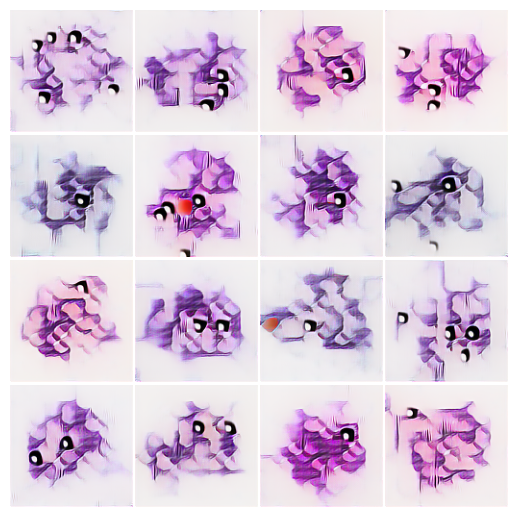

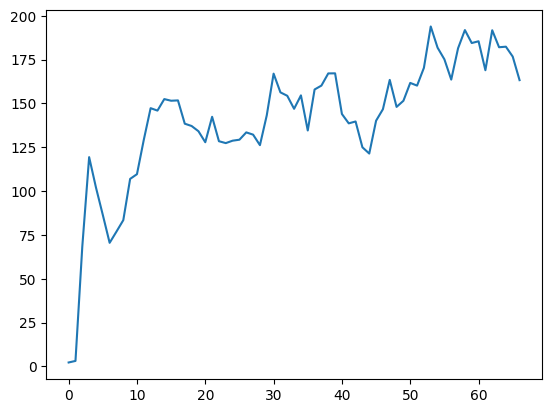

  7%|▋         | 6628/100000 [46:20<10:17:10,  2.52it/s, loss=1.96e+02]

In [ ]:
loss_history = train_drifting_with_vae(
    vae,
    transformer,
    opt,
    drifting_T=[0.02, 0.5, 2],
    # drifting_T=[0.02, 0.05, 0.2],
    batch_size=32,
    gradient_accumulation=1,#16,
    training_steps=100000,
    plot_every=100,
    seed=None,
    save_step=2500
)

In [ ]:
# transformer.load_state_dict(torch.load("checkpoints/try1/transformer_3_step2500.pth"))

<All keys matched successfully>

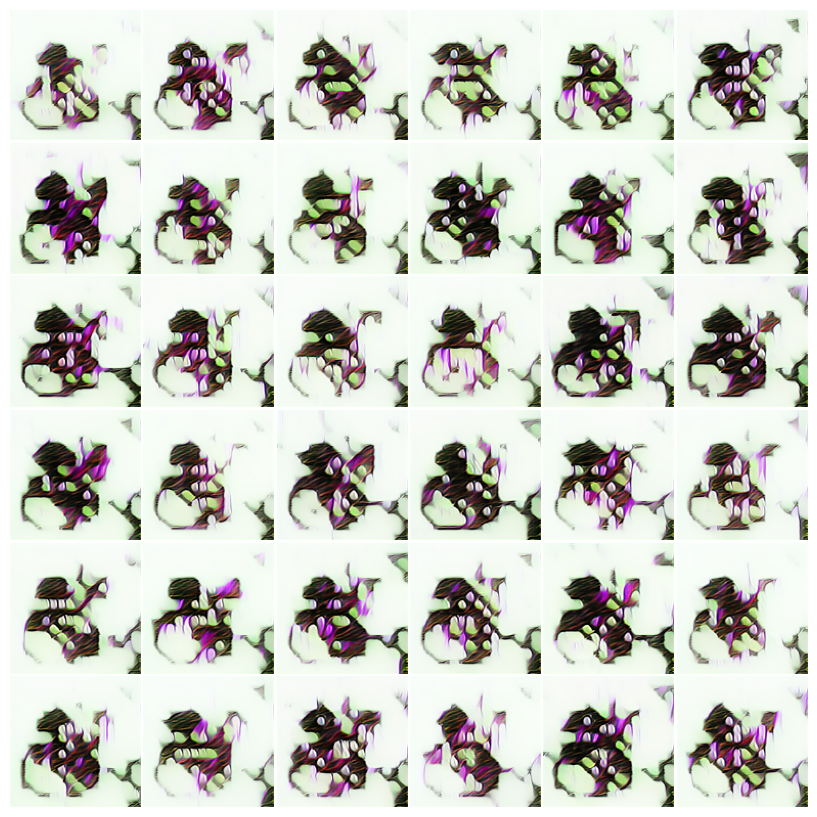

In [ ]:
# batch_size = 6**2
# initial_seed = 0

# # 6, 25
# with torch.no_grad():
#     noise = prepare_noise(
#         batch_size, 
#         (32, IMG_SIZE // 8, IMG_SIZE // 8), 
#         device=DEVICE, 
#         dtype=torch.bfloat16, 
#         initial_seed=initial_seed
#     )

#     gen_latent = transformer(noise)
#     gen = vae.decode(gen_latent).sample

#     clear_output(wait=True)
#     show_batch_grid(gen, n=6, figsize=(8, 8), denormalize=True)


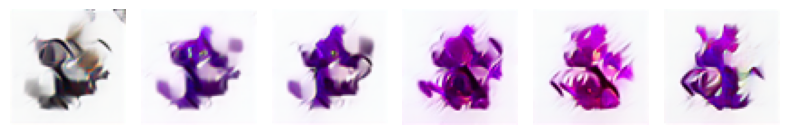

In [ ]:
# # noise_A = torch.stack([noise[5], noise[31]])

# noise_grad = []
# N = 6
# for alpha in range(N):
#     n = noise[5] * alpha / (N - 1) + noise[31] * (1 - alpha / (N - 1))
#     noise_grad.append(n)
# noise_grad = torch.stack(noise_grad)


# with torch.no_grad():
#     gen_latent = transformer(noise_grad)
#     gen = vae.decode(gen_latent).sample
#     clear_output(wait=True)
#     show_batch_grid(gen, n=6, figsize=(8, 8), denormalize=True)